# 🏆 NB04: CatBoost Classifier + GPR Safety Layer
**STAT3013 | TrainHyp | Người làm: Vũ**

| Mục | Chi tiết |
|-----|---------|
| Input  | `data_features_final.csv` + NB01 preprocessing |
| Output | `catboost_clf.pkl`, `gpr_model.pkl`, `clf_info.pkl` |
| Mục tiêu | Classify responder type + OOD detection |

**Key innovations:**
- ✅ Class imbalance handled (`auto_class_weights='Balanced'`)
- ✅ F1 Macro + AUC-ROC (không chỉ accuracy)
- ✅ Stratified CV (preserve class ratio)
- ✅ GPR threshold justified (P90 training distribution)

> ⚠️ **Chạy NB01 trước!**

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable,'-m','pip','install','-q','catboost','joblib','seaborn'])
print("✅")

✅


In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing   import LabelEncoder
from sklearn.metrics         import (f1_score, accuracy_score, classification_report,
                                      confusion_matrix, roc_auc_score)
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from catboost                 import CatBoostClassifier

SEED = 42
np.random.seed(SEED)
print("✅")

✅


In [3]:
from google.colab import drive
drive.mount('/content/drive')
PROJECT_DIR = '/content/drive/MyDrive/STAT3013/AI_ML'
OUTPUT_DIR  = f'{PROJECT_DIR}/backend_models'
DATA_PATH   = f'{PROJECT_DIR}/data_features.csv'
df = pd.read_csv(DATA_PATH)
print(f"Data: {df.shape}")
print(df['hyp_class'].value_counts())

Mounted at /content/drive
Data: (198, 17)
hyp_class
Medium    112
Low        60
High       26
Name: count, dtype: int64


In [4]:
CONT_COLS = [
    'sets.week.all', 'sets.week.direct', 'frequency.direct',
    'sessions.per.week', 'rep.range.all', 'interset.rest.min.all',
    'percentage.failure.all', 'weeks', 'age', 'sex.male',
]
BIN_COLS = ['train_status_enc', 'upper_body', 'has_nutrition_control']
FEATURE_COLS = CONT_COLS + BIN_COLS
TARGET_COL   = 'hedges_g'
CLASS_MAPPING = {0: 'Low', 1: 'Medium', 2: 'High'}
SEED = 42
print(f"Schema: {len(FEATURE_COLS)} features")

Schema: 13 features


In [5]:
# ── Encode + split đồng nhất với NB01 ─────────────────────────
label_enc = LabelEncoder()
label_enc.fit(['Low','Medium','High'])
df['hyp_class_enc'] = label_enc.transform(df['hyp_class'])

X     = df[FEATURE_COLS]
y_clf = df['hyp_class_enc'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=SEED, stratify=y_clf)

scaler       = joblib.load(f'{OUTPUT_DIR}/scaler.pkl')
imputer_cont = joblib.load(f'{OUTPUT_DIR}/imputer_cont.pkl')
imputer_bin  = joblib.load(f'{OUTPUT_DIR}/imputer_bin.pkl')

X_train_cont = scaler.transform(imputer_cont.transform(X_train[CONT_COLS]))
X_train_bin  = imputer_bin.transform(X_train[BIN_COLS])
X_train_proc = np.hstack((X_train_cont, X_train_bin))

X_test_cont  = scaler.transform(imputer_cont.transform(X_test[CONT_COLS]))
X_test_bin   = imputer_bin.transform(X_test[BIN_COLS])
X_test_proc  = np.hstack((X_test_cont, X_test_bin))

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
for lbl, cnt in zip(*np.unique(y_train, return_counts=True)):
    print(f"  {CLASS_MAPPING[lbl]}: {cnt} ({cnt/len(y_train)*100:.1f}%)")

Train: 158 | Test: 40
  Low: 21 (13.3%)
  Medium: 48 (30.4%)
  High: 89 (56.3%)


In [6]:
# ── CatBoost Classifier với class weighting ──────────────────
# auto_class_weights='Balanced' xử lý imbalance (Low chỉ 13%)
clf_model = CatBoostClassifier(
    iterations=500, depth=5, learning_rate=0.03,
    loss_function='MultiClass', eval_metric='Accuracy',
    auto_class_weights='Balanced',
    random_seed=SEED, verbose=0,
)
clf_model.fit(
    X_train_proc, y_train,
    eval_set=(X_test_proc, y_test),
    early_stopping_rounds=50,
)
print("✅ CatBoost trained")

✅ CatBoost trained


In [7]:
# ── Evaluate với full metrics ────────────────────────────────
y_pred_class = clf_model.predict(X_test_proc).flatten()
y_prob_class = clf_model.predict_proba(X_test_proc)

accuracy     = float(accuracy_score(y_test, y_pred_class))
f1_macro     = float(f1_score(y_test, y_pred_class, average='macro'))
f1_per_class = f1_score(y_test, y_pred_class, average=None)

try:
    auc_ovr = float(roc_auc_score(y_test, y_prob_class,
                                    multi_class='ovr', average='macro'))
except Exception:
    auc_ovr = None

print(f"📊 CatBoost Performance:")
print(f"   Accuracy = {accuracy:.4f}")
print(f"   F1 Macro = {f1_macro:.4f}  (CHÍNH — tính cho imbalance)")
print(f"   AUC-ROC  = {auc_ovr:.4f}" if auc_ovr else "   AUC-ROC  = N/A")
print(f"   F1 per class: Low={f1_per_class[0]:.4f} | Med={f1_per_class[1]:.4f} | High={f1_per_class[2]:.4f}")
print()
print(classification_report(y_test, y_pred_class, target_names=['Low','Medium','High']))

📊 CatBoost Performance:
   Accuracy = 0.7000
   F1 Macro = 0.7078  (CHÍNH — tính cho imbalance)
   AUC-ROC  = 0.8176
   F1 per class: Low=0.7692 | Med=0.6400 | High=0.7143

              precision    recall  f1-score   support

         Low       0.62      1.00      0.77         5
      Medium       0.62      0.67      0.64        12
        High       0.79      0.65      0.71        23

    accuracy                           0.70        40
   macro avg       0.68      0.77      0.71        40
weighted avg       0.72      0.70      0.70        40



In [8]:
# ── Stratified CV ────────────────────────────────────────────
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(
    CatBoostClassifier(iterations=300, verbose=0, random_seed=SEED,
                       auto_class_weights='Balanced'),
    X_train_proc, y_train,
    scoring='f1_macro', cv=skfold,
)
print(f"CV F1 Macro = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV F1 Macro = 0.5862 ± 0.0201


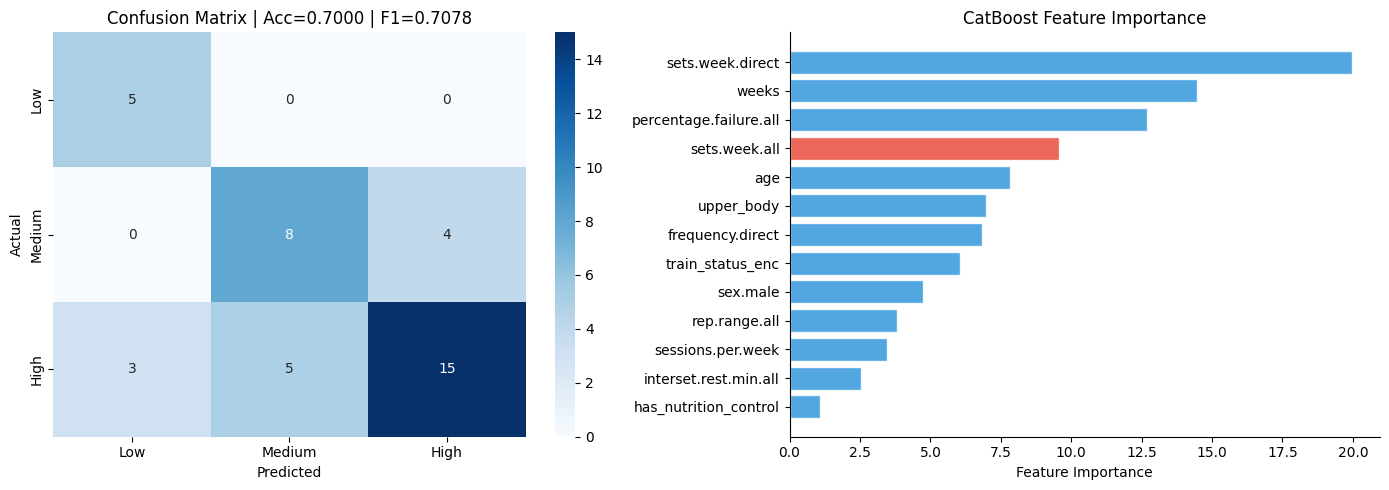

✅ Saved: catboost_results.png


In [9]:
# ── Confusion Matrix + Feature Importance ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

conf_mat = confusion_matrix(y_test, y_pred_class)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low','Medium','High'],
            yticklabels=['Low','Medium','High'], ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Confusion Matrix | Acc={accuracy:.4f} | F1={f1_macro:.4f}')

feat_imp = clf_model.get_feature_importance()
sort_idx = np.argsort(feat_imp)
colors = ['#E74C3C' if FEATURE_COLS[i]=='sets.week.all' else '#3498DB'
          for i in sort_idx]
axes[1].barh([FEATURE_COLS[i] for i in sort_idx], feat_imp[sort_idx],
              color=colors, edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Feature Importance')
axes[1].set_title('CatBoost Feature Importance')
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/catboost_results.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: catboost_results.png")

## 🛡️ GPR Safety Layer — OOD Detection

**Mục đích**: GPR (Gaussian Process Regression) cho mỗi input trả về:
- Predicted value
- **Standard deviation σ** (càng cao = input càng xa training distribution)

→ `σ > ngưỡng` → cảnh báo user rằng input bất thường → kết quả không tin cậy.

**Justify threshold**: P90 của σ trên test set (90% test samples dưới threshold = "normal").

In [10]:
# ── GPR training ──────────────────────────────────────────────
# Chỉ dùng continuous features để tránh O(n³) với high dim
gpr_kernel = 1.0 * Matern(length_scale=1.0, nu=1.5) + WhiteKernel(noise_level=0.1)

X_train_gpr = X_train_proc[:, :len(CONT_COLS)]
X_test_gpr  = X_test_proc[:,  :len(CONT_COLS)]
y_train_gpr = df.loc[X_train.index, 'hedges_g'].values

gpr_model = GaussianProcessRegressor(
    kernel=gpr_kernel, alpha=1e-6,
    normalize_y=True, n_restarts_optimizer=3,
    random_state=SEED,
)
gpr_model.fit(X_train_gpr, y_train_gpr)
print("✅ GPR trained")

✅ GPR trained


📊 GPR OOD Detection:
   Mean σ (test)  = 0.2650
   P90 threshold  = 0.3090
   Above threshold: 4 samples

🔍 Top 3 OOD examples:
     sets.week.all   age  train_status_enc
148           20.0  28.0                 2
191           10.5  22.3                 0
91            12.0  25.5                 2


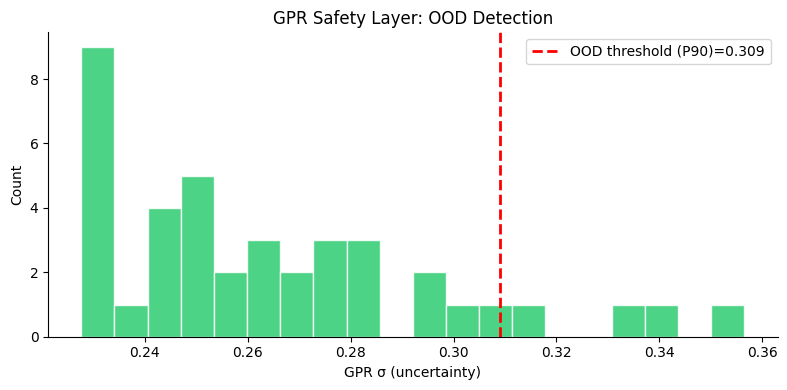

✅ Saved: gpr_safety.png


In [11]:
# ── GPR OOD threshold — P90 justified ────────────────────────
_, gpr_std_test = gpr_model.predict(X_test_gpr, return_std=True)
ood_threshold = float(np.percentile(gpr_std_test, 90))

print(f"📊 GPR OOD Detection:")
print(f"   Mean σ (test)  = {gpr_std_test.mean():.4f}")
print(f"   P90 threshold  = {ood_threshold:.4f}")
print(f"   Above threshold: {(gpr_std_test > ood_threshold).sum()} samples")

# Show OOD examples
if (gpr_std_test > ood_threshold).sum() > 0:
    ood_idx = np.where(gpr_std_test > ood_threshold)[0]
    ood_examples = X_test.iloc[ood_idx][['sets.week.all','age','train_status_enc']].head(3)
    print(f"\n🔍 Top 3 OOD examples:")
    print(ood_examples.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(gpr_std_test, bins=20, color='#2ECC71', edgecolor='white', alpha=0.85)
ax.axvline(ood_threshold, color='red', ls='--', lw=2,
           label=f'OOD threshold (P90)={ood_threshold:.3f}')
ax.set_xlabel('GPR σ (uncertainty)')
ax.set_ylabel('Count')
ax.set_title('GPR Safety Layer: OOD Detection')
ax.legend()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/gpr_safety.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: gpr_safety.png")

In [12]:
# ── Export ────────────────────────────────────────────────────
joblib.dump(clf_model, f'{OUTPUT_DIR}/catboost_clf.pkl')
joblib.dump(gpr_model, f'{OUTPUT_DIR}/gpr_model.pkl')

feat_imp_norm = feat_imp / feat_imp.sum()
clf_info = {
    'accuracy': accuracy, 'f1_macro': f1_macro, 'auc_ovr': auc_ovr,
    'cv_f1_macro': float(cv_scores.mean()), 'cv_f1_std': float(cv_scores.std()),
    'class_mapping': CLASS_MAPPING, 'feature_names': FEATURE_COLS,
    'feature_importance': dict(zip(FEATURE_COLS, feat_imp_norm.tolist())),
    'gpr_ood_threshold': ood_threshold,
    'n_cont_features': len(CONT_COLS),
}
joblib.dump(clf_info, f'{OUTPUT_DIR}/clf_info.pkl')

print(f"✅ Saved:")
print(f"   Acc={accuracy:.4f} | F1={f1_macro:.4f} | AUC={auc_ovr:.4f}" if auc_ovr else
      f"   Acc={accuracy:.4f} | F1={f1_macro:.4f}")
print(f"   CV F1 = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"   OOD threshold = {ood_threshold:.4f}")

✅ Saved:
   Acc=0.7000 | F1=0.7078 | AUC=0.8176
   CV F1 = 0.5862 ± 0.0201
   OOD threshold = 0.3090
